# **LIMPIEZA DE TEXTO**

In [ ]:
#pip install python-dotenv
#pip install openai
#pip install spacy unidecode
#python -m spacy download es_core_news_sm
#pip install fonttools
#pip install -q textblob
#pip install spacy
#python -m spacy download es_core_news_sm
#pip install wordcloud
#pip install ufal.udpipe
#pip install pyspellchecker
#wget https://lindat.mff.cuni.cz/repository/xmlui/bitstream/handle/11234/1-3131/spanish-gsd-ud-2.5-191206.udpipe
#python -m spacy download es_core_news_sm
#python -m spacy download es_core_news_md
#pip install igraph

In [ ]:
from textblob import TextBlob
import spacy
nlp = spacy.load("es_core_news_sm")
from dotenv import load_dotenv
import openai
import os
import re
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import networkx as nx
import matplotlib.pyplot as plt
import nltk
import numpy as np
nltk.download('stopwords')
nltk.download('words')
import pandas as pd
nltk.download('punkt')
import random
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro, bartlett, pearsonr
import community
from wordcloud import WordCloud
from nltk.probability import FreqDist
import subprocess
import pickle
import igraph as ig
import unidecode
from itertools import combinations
from collections import Counter
from unidecode import unidecode
import math
nltk.download('punkt_tab')
from tqdm import tqdm
from nltk import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import unicodedata

In [3]:
#FUNCIONES DE LIMPIEZA DE TEXTO
def limpiar_texto(texto):
    # Convertir texto a minúsculas
    texto = texto.lower()

    # Quitar caracteres especiales y números
    texto = re.sub(r'[^a-zA-ZñÑáéíóúÁÉÍÓÚó\s]', '', texto)
    texto = ''.join((c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn'))

    return texto

def quitar_stopwords(texto):
    # Tokenizar el texto
    tokens = word_tokenize(texto)

    # Quitar stopwords
    texto_limpio = [word for word in tokens if word not in stop_words]

    return ' '.join(texto_limpio)


def generar_skipgramas(texto, n=2, k=2):
    tokens = word_tokenize(texto)
    skipgramas = []
    for i in range(len(tokens)):
        for j in range(i + 1, min(i + k + 2, len(tokens))):
            skipgramas.append((tokens[i], tokens[j]))

    return skipgramas


def eliminar_palabras_cortas(texto):
    excepciones = {"up", "fé", "fe"}  # palabras que no queremos eliminar como UP(unión patriótica) y fe
    palabras = texto.split()
    palabras_filtradas = [
        palabra for palabra in palabras
        if len(palabra) > 2 or palabra.lower() in excepciones
    ]
    texto_filtrado = ' '.join(palabras_filtradas)
    return texto_filtrado


In [ ]:
from unidecode import unidecode
carpeta = 'C:/Users/Desktop/caso_05'

textos_20240910 = []
textos_20240911 = []
textos_vgenero = []

for archivo in os.listdir(carpeta):
    if archivo.endswith('.txt'):
        ruta_archivo = os.path.join(carpeta, archivo)
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()

        # normalizar: minúsculas, quitar tildes y signos
        archivo_norm = unidecode(archivo.lower())
        archivo_norm = archivo_norm.replace(',', '').replace('-', ' ').replace('_', ' ')

        if '20240910' in archivo_norm:
            textos_20240910.append((archivo, contenido))
        elif '20240911' in archivo_norm:
            textos_20240911.append((archivo, contenido))
        else:
            textos_vgenero.append((archivo, contenido))

texto_20240910 = ' '.join([contenido for _, contenido in textos_20240910])
texto_20240911 = ' '.join([contenido for _, contenido in textos_20240911])
texto_vgenero = ' '.join([contenido for _, contenido in textos_vgenero])

print(f"Archivos de Audiencia 1: {len(textos_20240910)}")
print(f"Archivos de Audiencia 2: {len(textos_20240911)}")
print(f"Audiencia V. Género: {len(textos_vgenero)}")


Archivos de Audiencia 1: 1
Archivos de Audiencia 2: 1
Audiencia V. Género: 1


In [ ]:
# primera lematizacion
lematizaciones = {}
with open('C:/Users/Desktop/Casos_JEP/lematizacion.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones[palabra.strip()] = lema.strip()

def aplicar_lematizacion(texto, lematizaciones):
    palabras = texto.split()
    palabras_lematizadas = [lematizaciones.get(palabra.lower(), palabra) for palabra in palabras]
    return ' '.join(palabras_lematizadas)
textos = {  'Audiencia 1': texto_20240910,'Audiencia 2': texto_20240911,'Audiencia V. Género' :texto_vgenero}

textos_lematizados = {}
for nombre, texto in textos.items():
    textos_lematizados[nombre] = aplicar_lematizacion(texto, lematizaciones)
    print(textos_lematizados[nombre][:500])
texto_A1_lem = textos_lematizados['Audiencia 1']
texto_A2_lem = textos_lematizados['Audiencia 2']
texto_VG_lem = textos_lematizados['Audiencia V. Género']


#Eliminar palabras cortas:
texto_A1_final = eliminar_palabras_cortas(texto_A1_lem)
texto_A2_final = eliminar_palabras_cortas(texto_A2_lem)
texto_VG_final = eliminar_palabras_cortas(texto_VG_lem)


#Tokenizar
textos = {'Audiencia 1': texto_A1_final,'Audiencia 2': texto_A2_final,'Audiencia V. Género' :texto_VG_final}
tokens_dict = {}
for nombre, texto in textos.items():
    tokens = nltk.word_tokenize(texto, language="spanish")
    tokens_dict[nombre] = tokens

# **LEMATIZACIÓN Y CORRECCIÓN PREVIA**

In [ ]:
# cargar modelo español solo con lematización de spacy:
nlp = spacy.load("es_core_news_md", disable=["parser","ner"])
##Lematizar por bloques de 10.000 tokens:
def lematizar_en_bloques(tokens, bloque_size=10000):
    lemas = []
    for i in tqdm(range(0, len(tokens), bloque_size)):
        bloque = tokens[i:i+bloque_size]
        docs = nlp.pipe(bloque, disable=["parser","ner"])
        for doc in docs:
            for token in doc:
                lemas.append(token.lemma_)
    return lemas

for nombre, tokens in tokens_dict.items():
    print(f"\n Texto: {nombre} ({len(tokens)} tokens)")
    lemas = lematizar_en_bloques(tokens, bloque_size=10000)

    nombre_archivo = f"solo_lemas_{nombre}.txt"
    with open(nombre_archivo, "w", encoding="utf-8") as f:
        for lema in lemas:
            f.write(lema + "\n")

In [ ]:
##reconstruir los textos:
textos_lemas = {}

for nombre in ["Audiencia 1", "Audiencia 2", "Audiencia V. Género"]:
    with open(f"solo_lemas_{nombre}.txt", "r", encoding="utf-8") as f:
        lemas = [line.strip() for line in f if line.strip()]
    texto_lemas = " ".join(lemas)
    textos_lemas[nombre] = texto_lemas

# Lematizaciones personalizadas por caso:
lematizaciones2 = {}
with open('C:/Users/Desktop/Casos_JEP/salida_05.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones2[palabra.strip()] = lema.strip()

textos_finales_dicc = {}
for nombre, texto in textos_lemas.items():
    palabras = texto.split()

    texto_lemas_dicc = []
    for palabra in palabras:
        if palabra in lematizaciones2:
            if lematizaciones2[palabra] != "NA":
                texto_lemas_dicc.append(lematizaciones2[palabra])
            # si es "NA", no se agrega nada (se elimina)
        else:
            texto_lemas_dicc.append(palabra)

    texto_final = " ".join(texto_lemas_dicc)
    textos_finales_dicc[nombre] = texto_final

# **GENERAR SKIPGRAMAS**

In [ ]:
def eliminar_acentos(palabra):
    return ''.join(c for c in unicodedata.normalize('NFD', palabra) if unicodedata.category(c) != 'Mn')

def normalizar(texto):
    return eliminar_acentos(texto.lower())

# -------------------------------Stopwords------------------------------------
stop_words = set(stopwords.words('spanish'))
archivo_stopwords = 'C:/Users/Desktop/Casos_JEP/stop_words_espanol.txt'

with open(archivo_stopwords, 'r', encoding='utf-8') as f:
    for line in f:
        word = line.strip()
        stop_words.add(word)

with open(archivo_stopwords, 'r') as f:
    for linea in f:
        for palabra in linea.split():
            stop_words.add(eliminar_acentos(palabra.lower()))
#-------------------------- Palabras no válidas y lemas--------------------------
ruta_palabras = "C:/Users/Desktop/Casos_JEP/palabras_no_validas.txt"
ruta_lemas = "C:/Users/Desktop/Casos_JEP/lemas_lemas.txt"

with open(ruta_palabras, "r", encoding="utf-8") as f:
    palabras_no_validas = [line.strip() for line in f if line.strip()]

lematizaciones_final = {}
lemas_set = set()
with open(ruta_lemas, "r", encoding="utf-8") as f:
    for linea in f:
        if ":" in linea:
            palabra, lema = linea.strip().split(":")
            palabra_norm = normalizar(palabra.strip())
            lema_norm = normalizar(lema.strip())
            lematizaciones_final[palabra_norm] = lema_norm
            lemas_set.add(palabra_norm)

filtradas = [p for p in palabras_no_validas if p not in lemas_set]

#----------------------- Limpiar, lematizar y filtrar textos-------------------------------
textos_finales_limpios = {nombre: limpiar_texto(texto) for nombre, texto in textos_finales_dicc.items()}

textos_lema_dicc = {
    nombre: " ".join(lematizaciones_final.get(p, p) for p in texto.split())
    for nombre, texto in textos_finales_limpios.items()
}

textos_filtrados = {
    nombre: " ".join(p for p in texto.split() if p not in filtradas)
    for nombre, texto in textos_lema_dicc.items()
}

#--------------------------------Skipgramas--------------------------------------------------------------
textos_skipgramas = {}
for nombre, texto_filtrado in textos_lema_dicc.items():
    texto_sin_stopwords = quitar_stopwords(texto_filtrado)
    tokens = word_tokenize(texto_sin_stopwords)
    frec = Counter(tokens)
    tokens_filtrados = [t for t in tokens if frec[t] > 1]
    texto_dep = " ".join(tokens_filtrados)
    textos_skipgramas[nombre] = {
        "texto_sin_stopwords": texto_dep,
        "skipgramas": generar_skipgramas(texto_dep, 2, 2)
    }

In [26]:
##eliminar bucles en skipgramas
textos_skipgramas_filtrados = {}
for nombre, datos in textos_skipgramas.items():
    skipgramas = datos["skipgramas"]

    # Eliminar bucles (a, a)
    skipgramas_sin_bucles = [b for b in skipgramas if b[0] != b[1]]
    conteo = Counter(skipgramas_sin_bucles)
    # Conservar solo los skipgramas con frecuencia > 1
    skipgramas_filtrados = [b for b, f in conteo.items() if f > 1]

    # Guardar en diccionario
    textos_skipgramas_filtrados[nombre] = {
        "texto_sin_stopwords": datos["texto_sin_stopwords"],
        "skipgramas_filtrados": skipgramas_filtrados,
        "frecuencias": conteo}

#calcular frecuencias
tablas_frecuencias = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    conteo = datos["frecuencias"]
    conteo_str = {' '.join(k): v for k, v in conteo.items() if v > 1}
    df_top = pd.DataFrame(Counter(conteo_str).most_common(10), columns=["Skipgrama", "Frecuencia"])
    tablas_frecuencias[nombre] = df_top

    print(f"\nTop 10 skipgramas en '{nombre}':")
    display(df_top)


Top 10 skipgramas en 'Audiencia 1':


,Skipgrama,Frecuencia
0,norte cauca,81
1,sur valle,66
2,valle cauca,54
3,cauca valle,49
4,autoridad indigena,38
5,cauca sur,37
6,pueblo indigena,37
7,ministerio interior,37
8,departamento cauca,36
9,comunidad indigena,35



Top 10 skipgramas en 'Audiencia 2':


,Skipgrama,Frecuencia
0,departamento cauca,38
1,valle cauca,36
2,pueblo indigena,31
3,comunidad indigena,28
4,norte cauca,28
5,plan desarrollo,26
6,autoridad indigena,25
7,medida cautelar,21
8,gobernacion cauca,20
9,acordar paz,20



Top 10 skipgramas en 'Audiencia V. Género':


,Skipgrama,Frecuencia
0,violencia sexual,95
1,victima violencia,41
2,victima sexual,33
3,jurisdiccion especial,27
4,violencia mujer,23
5,mujer violencia,22
6,mujer victima,22
7,jurisdiccion paz,18
8,especial paz,18
9,sexual violencia,17


# **ANÁLISIS DESCRIPTIVO**

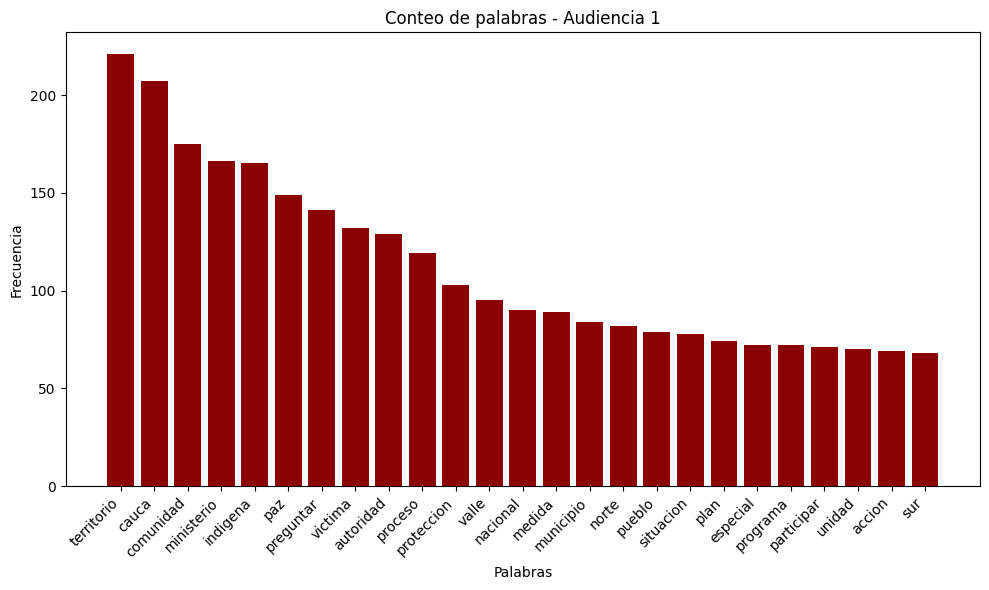

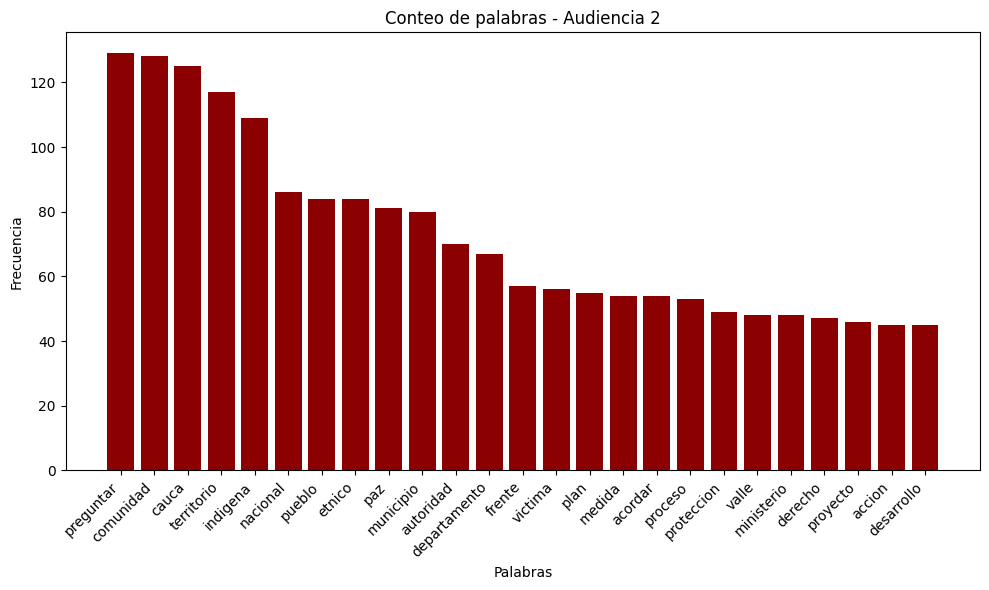

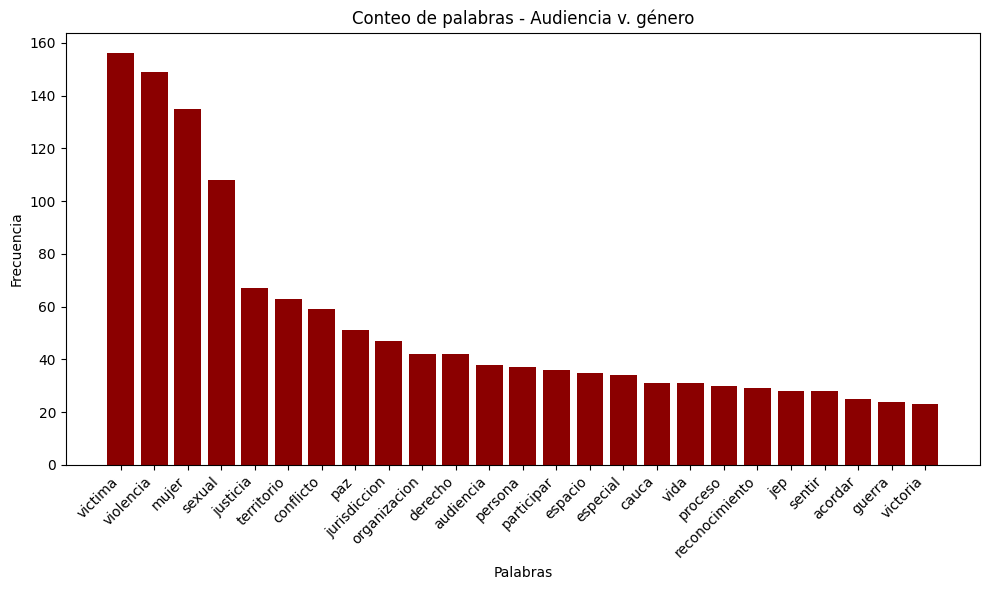

In [27]:
##Distribución de frecuencias
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(25)
    palabras, frecuencias = zip(*palabras_repetidas)

    plt.figure(figsize=(10, 6))
    plt.bar(palabras, frecuencias, color="darkred")
    plt.xlabel('Palabras')
    plt.ylabel('Frecuencia')
    plt.title(f"Conteo de palabras - {nombre.capitalize()}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
##Frecuencia de palabras por subanálisis:
tablas_frecuencias = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()

    # Calcular frecuencias
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(15)

    tabla_frecuencias = pd.DataFrame(palabras_repetidas, columns=['Palabra', 'Frecuencia'])
    tablas_frecuencias[nombre] = tabla_frecuencias

    print(f"\n Frecuencias para: {nombre}")
    print(tabla_frecuencias)

tabla_final = pd.concat(tablas_frecuencias, names=['Grupo']).reset_index(level=0)
tabla_final.reset_index(drop=True, inplace=True)



 Frecuencias para: Audiencia 1
       Palabra  Frecuencia
0   territorio         221
1        cauca         207
2    comunidad         175
3   ministerio         166
4     indigena         165
5          paz         149
6    preguntar         141
7      victima         132
8    autoridad         129
9      proceso         119
10  proteccion         103
11       valle          95
12    nacional          90
13      medida          89
14   municipio          84

 Frecuencias para: Audiencia 2
         Palabra  Frecuencia
0      preguntar         129
1      comunidad         128
2          cauca         125
3     territorio         117
4       indigena         109
5       nacional          86
6         pueblo          84
7         etnico          84
8            paz          81
9      municipio          80
10     autoridad          70
11  departamento          67
12        frente          57
13       victima          56
14          plan          55

 Frecuencias para: Audiencia V. Género


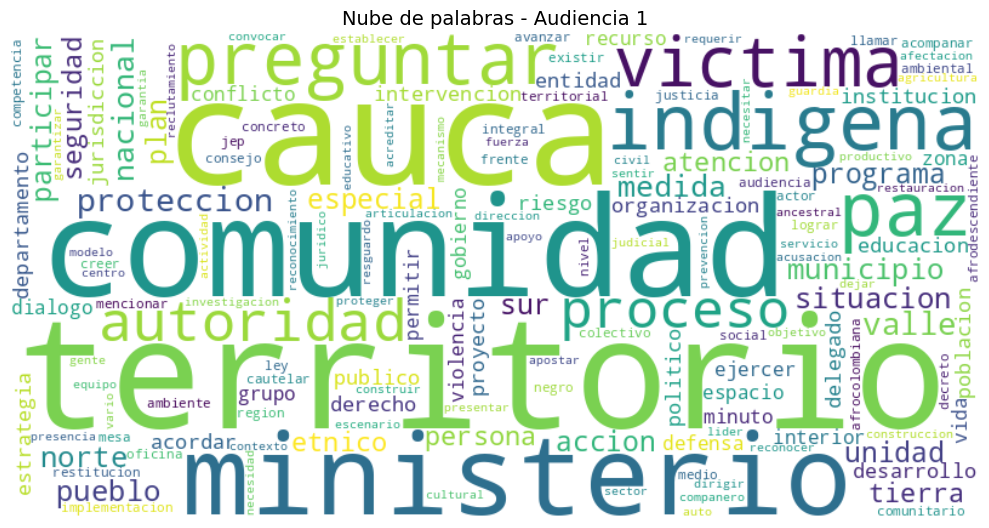

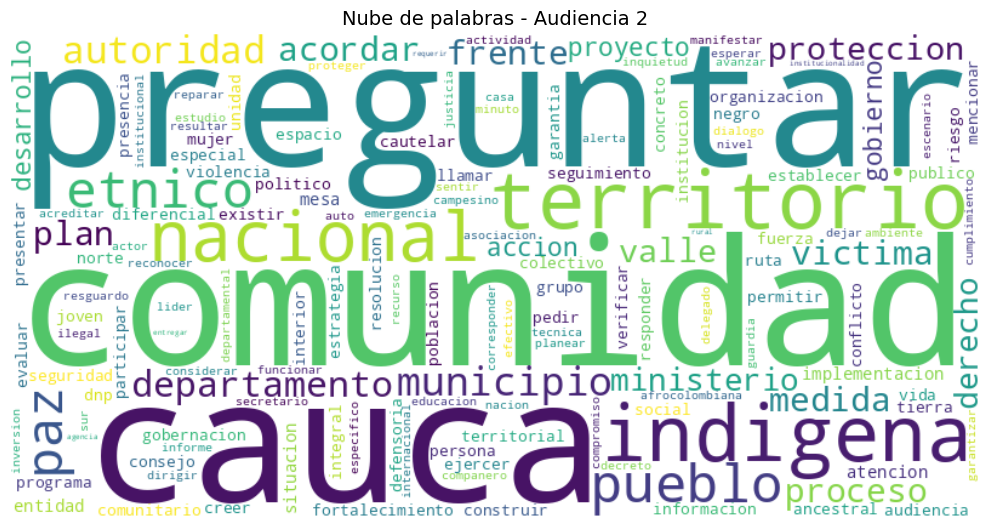

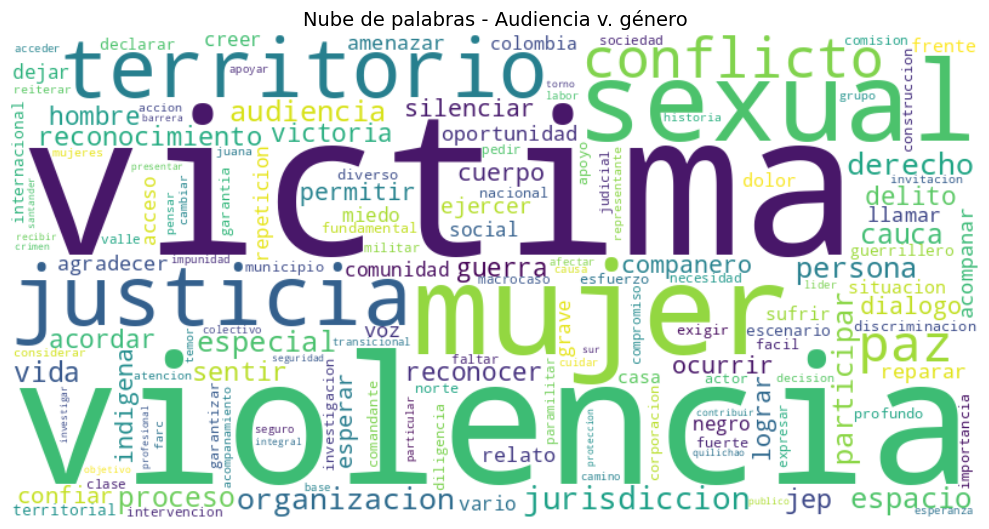

In [29]:
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)

    nube = WordCloud(width=800, height=400,
        background_color='white',
        max_words=150
    ).generate_from_frequencies(frecuencia_palabras)

    plt.figure(figsize=(10, 6))
    plt.imshow(nube, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nube de palabras - {nombre.capitalize()}", fontsize=14)
    plt.tight_layout()
    plt.show()


# **ANÁLISIS DE SENTIMIENTO**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

ruta_excel = "C:/Users/Desktop/Casos_JEP/emociones.xlsx"
lexico = pd.read_excel(ruta_excel, engine="openpyxl")
lexico = lexico.rename(columns={'Spanish Translation': 'Palabra'})

lexico['Palabra'] = (
    lexico['Palabra'].astype(str).str.lower().str.strip().apply(unidecode).str.replace(r'[^a-zñáéíóúü\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True))

columnas_emociones = [
    'Positive','Negative','Anger','Anticipation','Disgust','Fear','Joy','Sadness','Surprise','Trust']

lexico[columnas_emociones] = lexico[columnas_emociones].fillna(0).astype(int)
lexico = lexico.groupby('Palabra', as_index=False)[columnas_emociones].max()
emociones = lexico.set_index('Palabra').to_dict(orient='index')


resultados = []
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]

    # Normalizar
    tokens = [ re.sub(r'\s+', ' ',re.sub(r'[^a-zñáéíóúü\s]', '',
                      unidecode(t.lower().strip())))
        for t in word_tokenize(texto)]

    conteo = Counter({emo: 0 for emo in columnas_emociones})

    for token in tokens:
        if token in emociones:
            for emo, valor in emociones[token].items():
                conteo[emo] += valor

    conteo['Texto'] = nombre
    resultados.append(conteo)

df_emociones = pd.DataFrame(resultados)
df_emociones = df_emociones[['Texto'] + columnas_emociones]

# Traducir nombres de columnas
df_emociones = df_emociones.rename(columns={'Positive': 'Positivo','Negative': 'Negativo','Anger': 'Ira',
    'Anticipation': 'Anticipación','Disgust': 'Disgusto','Fear': 'Miedo','Joy': 'Alegría','Sadness': 'Tristeza',
    'Surprise': 'Sorpresa', 'Trust': 'Confianza'})
print(df_emociones.head())


                 Texto  Positivo  Negativo  Ira  Anticipación  Disgusto  \
0          Audiencia 1      3305      1147  608          1083       352   
1          Audiencia 2      1619       571  258           662       139   
2  Audiencia V. Género      1000       826  621           451       140   

   Miedo  Alegría  Tristeza  Sorpresa  Confianza  
0    949      801       684       316       2093  
1    432      378       327       186       1052  
2    675      309       618       189        674  


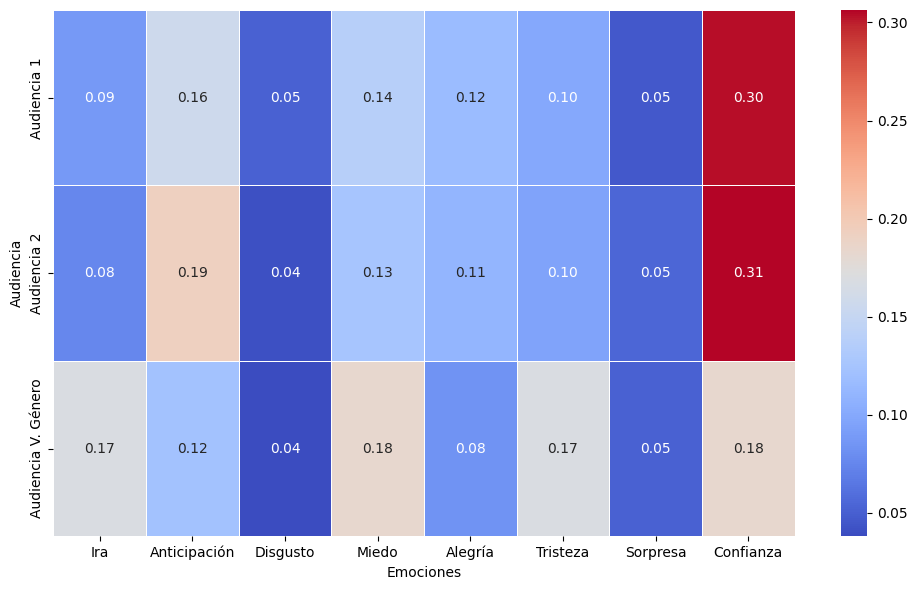

In [31]:
#Mapa de calor de emociones
columnas_emociones = ["Ira" , "Anticipación" , "Disgusto" ,  "Miedo",  "Alegría" , "Tristeza" , "Sorpresa", "Confianza"]
df_heatmap = df_emociones[['Texto'] + columnas_emociones].copy()
df_heatmap.set_index('Texto', inplace=True)
df_heatmap_norm = df_heatmap.div(df_heatmap.sum(axis=1), axis=0)

plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap_norm, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.xlabel('Emociones')
plt.ylabel('Audiencia')
plt.tight_layout()
plt.show()

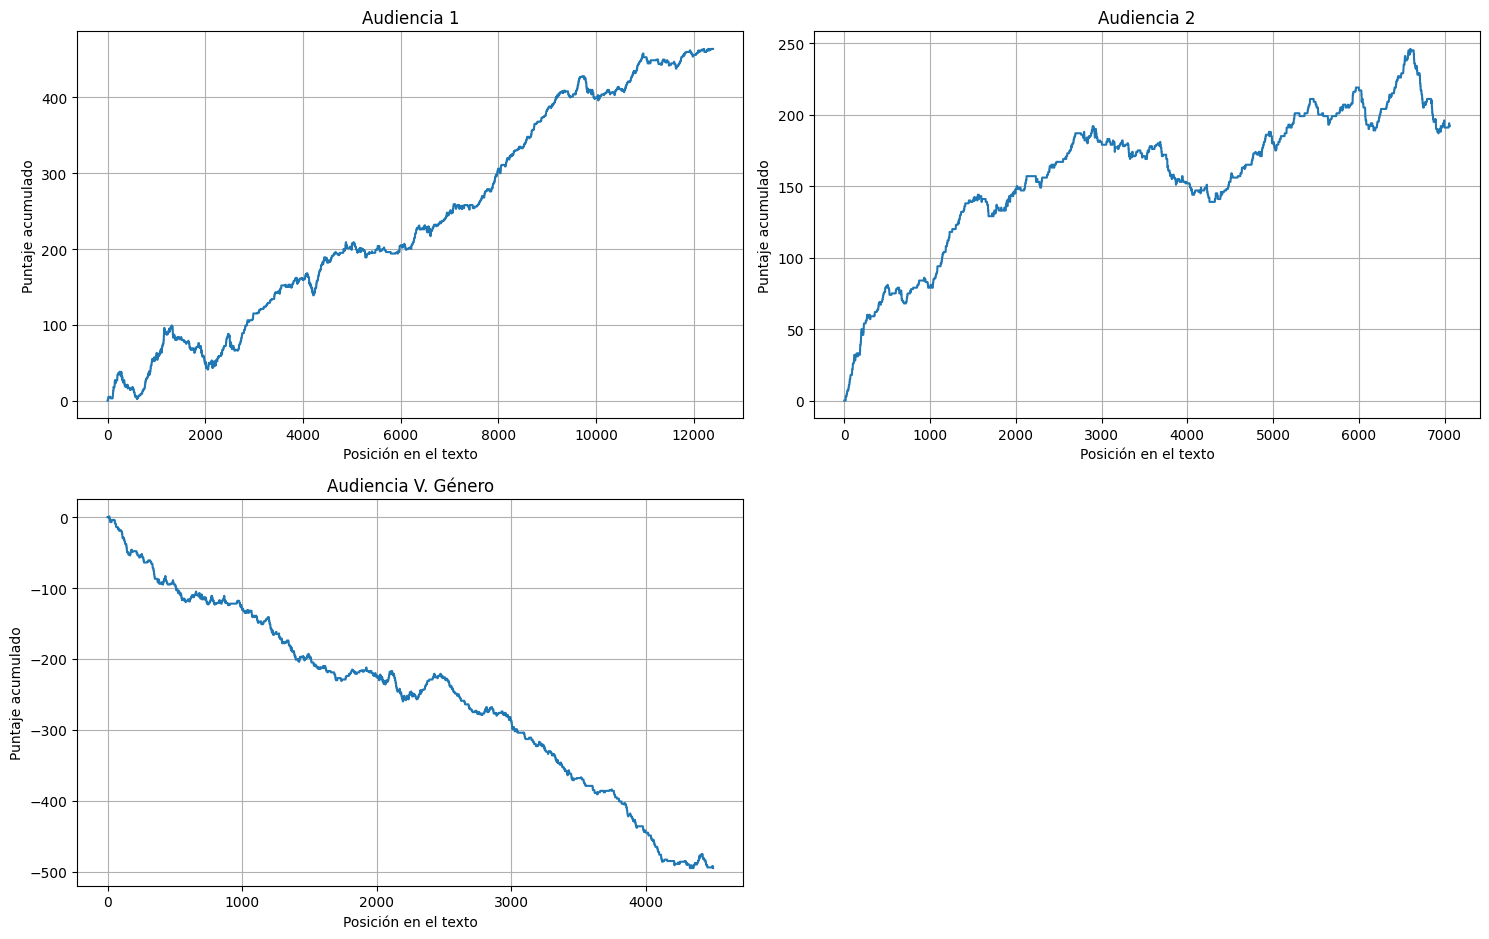

In [ ]:
##Grafico de sentimiento acumulado mediante diccionario AFINN
afinn = pd.read_csv("C:/Users/Desktop/Casos_JEP/material_adicional/lexico_afinn.csv")
afinn['palabra'] = afinn['palabra'].str.lower().str.strip()
afinn_dict = dict(zip(afinn['palabra'], afinn['puntuacion']))

tendencias_afinn = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = [
        unidecode(t.lower().strip())
        for t in word_tokenize(texto)]
    puntajes = [
        afinn_dict.get(token, 0)
        for token in tokens]

    df = pd.DataFrame({"palabra": tokens, "puntaje": puntajes})
    df["sentimiento_acumulado"] = df["puntaje"].cumsum()
    tendencias_afinn[nombre] = df

n = len(tendencias_afinn)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5* nrows))
axes = axes.flatten()

for ax, (nombre, df) in zip(axes, tendencias_afinn.items()):
    ax.plot(df.index, df["sentimiento_acumulado"])
    ax.set_title(f"{nombre}")
    ax.set_xlabel("Posición en el texto")
    ax.set_ylabel("Puntaje acumulado")
    ax.grid(True)

for i in range(len(tendencias_afinn), len(axes)):
    axes[i].axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# **RED BASICA**

In [ ]:
def get_gigante(G):
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()

# ----------------------- Cálculo de métricas --------------------------------------------
redes_metrics = {}
centralidades_por_red = {}
top10_grado_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    skipgramas = datos["skipgramas_filtrados"]

    G = nx.Graph()
    G.add_edges_from(skipgramas)

    if G.number_of_nodes() == 0:
        print(f"Grafo '{nombre}' vacío.")
        continue

    G_gigante = get_gigante(G)

    if G_gigante.number_of_nodes() < 2:
        print(f"Grafo '{nombre}' con componente pequeña.")
        continue

    # Métricas básicas
    num_nodos = G_gigante.number_of_nodes()
    num_aristas = G_gigante.number_of_edges()
    grados = dict(G_gigante.degree())

    # Top 10 por grado
    top10_grado = (
        pd.DataFrame(grados.items(), columns=["nodo", "grado"])
        .sort_values("grado", ascending=False)
        .head(10)
        .assign(porcentaje_grado=lambda x: x["grado"] / (2 * num_aristas))
    )
    top10_grado_por_red[nombre] = top10_grado

    # Centralidades
    nodos = list(G_gigante.nodes())
    betweenness = nx.betweenness_centrality(G_gigante, k=min(500, num_nodos), normalized=True, seed=42)
    closeness = nx.closeness_centrality(G_gigante)
    eigenvector = nx.eigenvector_centrality(G_gigante, max_iter=1000, tol=1e-6)

    df_centralidad = pd.DataFrame({
        "nodo": nodos,
        "grado": [grados[n] for n in nodos],
        "betweenness": [betweenness[n] for n in nodos],
        "closeness": [closeness[n] for n in nodos],
        "eigenvector": [eigenvector[n] for n in nodos]
    })
    centralidades_por_red[nombre] = df_centralidad

    redes_metrics[nombre] = {
        "num_nodos": num_nodos,
        "num_aristas": num_aristas,
        "densidad": nx.density(G_gigante),
        "grado_promedio": sum(grados.values()) / num_nodos,
        "transitividad_global": nx.transitivity(G_gigante),
        "assortatividad_grado": nx.degree_assortativity_coefficient(G_gigante),
        "diametro": nx.diameter(G_gigante),
        "longitud_media_camino": nx.average_shortest_path_length(G_gigante),
        "betweenness_media": df_centralidad["betweenness"].mean(),
        "betweenness_max": df_centralidad["betweenness"].max(),
        "closeness_media": df_centralidad["closeness"].mean(),
        "eigenvector_media": df_centralidad["eigenvector"].mean(),
        "grado_max": top10_grado["grado"].max(),
        "grado_medio_top10": top10_grado["grado"].mean(),
        "concentracion_top10": top10_grado["grado"].sum() / (2 * num_aristas),
    }

    print(f"Grafo '{nombre}': {num_nodos} nodos, {num_aristas} aristas (componente gigante).")

df_metrics = pd.DataFrame.from_dict(redes_metrics, orient="index")
print("\nMétricas")
print(df_metrics)

Grafo 'Audiencia 1': 989 nodos, 4535 aristas (componente gigante).
Grafo 'Audiencia 2': 698 nodos, 2560 aristas (componente gigante).
Grafo 'Audiencia V. Género': 494 nodos, 1405 aristas (componente gigante).

Métricas
                     num_nodos  num_aristas  densidad  grado_promedio  \
Audiencia 1                989         4535  0.009282        9.170880   
Audiencia 2                698         2560  0.010524        7.335244   
Audiencia V. Género        494         1405  0.011538        5.688259   

                     transitividad_global  assortatividad_grado  diametro  \
Audiencia 1                      0.157824             -0.115235         8   
Audiencia 2                      0.159267             -0.113885         7   
Audiencia V. Género              0.133824             -0.195514        10   

                     longitud_media_camino  betweenness_media  \
Audiencia 1                       3.135740           0.002172   
Audiencia 2                       3.200635       

In [34]:
top10_grado_por_red

{'Audiencia 1':            nodo  grado  porcentaje_grado
 48   territorio    220          0.024256
 4     comunidad    160          0.017641
 114       cauca    158          0.017420
 184   preguntar    139          0.015325
 226  ministerio    127          0.014002
 10          paz    125          0.013782
 16     indigena    123          0.013561
 15      victima    119          0.013120
 180     proceso    103          0.011356
 74    autoridad     95          0.010474,
 'Audiencia 2':            nodo  grado  porcentaje_grado
 94    preguntar    126          0.024609
 40    comunidad    118          0.023047
 62   territorio    113          0.022070
 90        cauca     99          0.019336
 4      indigena     95          0.018555
 121   municipio     75          0.014648
 15          paz     73          0.014258
 120      etnico     70          0.013672
 66     nacional     70          0.013672
 43       pueblo     66          0.012891,
 'Audiencia V. Género':              nodo  g